In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os
from collections import defaultdict
from itertools import combinations
import warnings

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

# Cross-paper cell type matching by marker gene profiles

For each (paper, cell_type) pair, build a binary marker gene set. Compute pairwise
Jaccard similarity to find cell types across papers that share marker genes but may
have been named differently.

## Load data

In [2]:
MECA_DIR = "../data/biorxiv/meca"

# Build (paper_id, cell_type) -> set of genes
# Restrict to human records and mapped Ensembl IDs only (feature_id)
profiles = {}  # key: (paper_id, cell_type), value: set of Ensembl IDs
all_records = []
n_mapped = 0
n_total = 0
n_skipped_nonhuman = 0

# For display: gene_id -> gene_name mapping
gene_id_to_name = {}

for folder in sorted(os.listdir(MECA_DIR)):
    fpath = os.path.join(MECA_DIR, folder)
    markers_path = os.path.join(fpath, "markers.json")
    if not os.path.isdir(fpath) or not os.path.exists(markers_path):
        continue

    with open(markers_path) as f:
        markers = json.load(f)

    for m in markers:
        # Filter to human only
        organism = m.get("organism", "").strip().lower()
        if organism != "homo_sapiens":
            n_skipped_nonhuman += 1
            continue

        ct = m.get("group_name", "").strip().upper()
        gene_name = m.get("feature_name", "").strip().upper()
        gene_id = m.get("feature_id")  # Ensembl ID (may be None)
        if not ct or not gene_name:
            continue

        n_total += 1
        if not gene_id:
            continue

        n_mapped += 1
        gene = gene_id
        gene_id_to_name[gene_id] = gene_name

        key = (folder, ct)
        if key not in profiles:
            profiles[key] = set()
        profiles[key].add(gene)

        all_records.append({
            "paper_id": folder,
            "cell_type": ct,
            "gene": gene,
            "gene_name": gene_name,
            "gene_id": gene_id,
        })

records_df = pd.DataFrame(all_records)
print(f"Total (paper, cell_type) profiles: {len(profiles):,}")
print(f"Total records (human, mapped): {len(records_df):,}")
print(f"Skipped non-human records: {n_skipped_nonhuman:,}")
print(f"Unique papers: {records_df['paper_id'].nunique()}")
print(f"Unique cell type names: {records_df['cell_type'].nunique():,}")
print(f"Unique Ensembl IDs: {records_df['gene'].nunique():,}")
print(f"Gene ID mapping: {n_mapped}/{n_total} ({n_mapped/n_total*100:.1f}%) mapped to Ensembl IDs")

def gene_display(gene):
    """Convert Ensembl ID to readable name for display."""
    return gene_id_to_name.get(gene, gene)


Total (paper, cell_type) profiles: 2,633
Total records (human, mapped): 8,395
Skipped non-human records: 3,580
Unique papers: 346
Unique cell type names: 1,965
Unique Ensembl IDs: 2,566
Gene ID mapping: 8395/8921 (94.1%) mapped to Ensembl IDs


Markers per (paper, cell_type):
  Mean:   3.1
  Median: 2
  Min:    1
  Max:    50


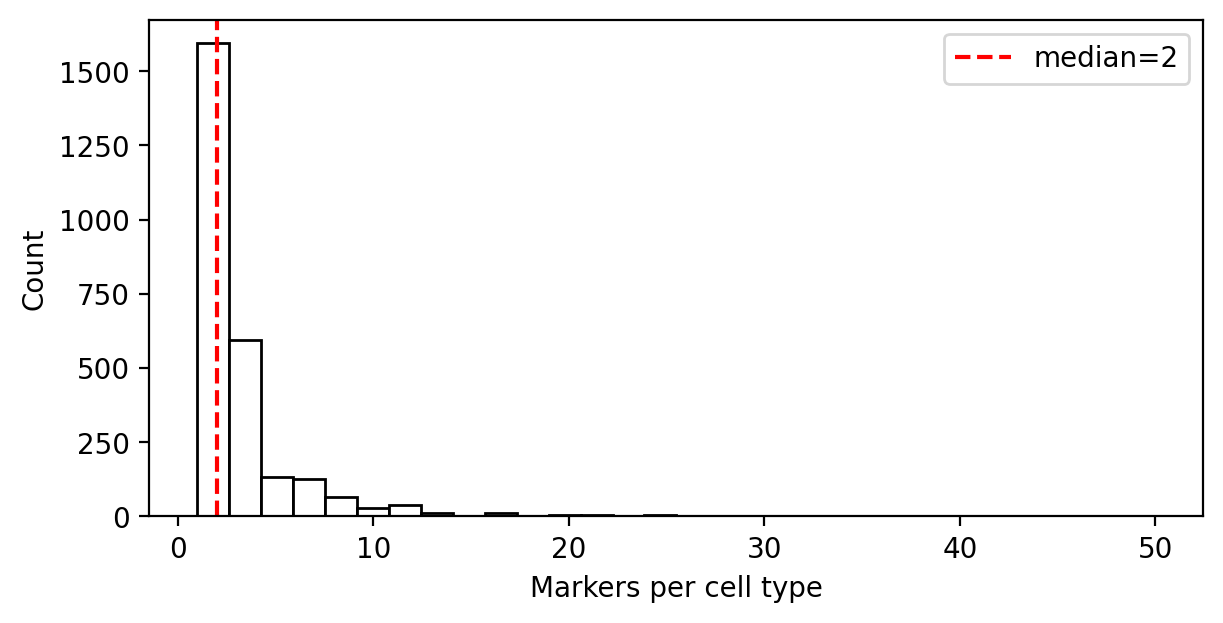

In [3]:
# Profile sizes
profile_sizes = [len(v) for v in profiles.values()]
print(f"Markers per (paper, cell_type):")
print(f"  Mean:   {np.mean(profile_sizes):.1f}")
print(f"  Median: {np.median(profile_sizes):.0f}")
print(f"  Min:    {np.min(profile_sizes)}")
print(f"  Max:    {np.max(profile_sizes)}")

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.hist(profile_sizes, bins=30, edgecolor="k", facecolor="white")
ax.axvline(np.median(profile_sizes), color="red", ls="--",
           label=f"median={np.median(profile_sizes):.0f}")
ax.set(xlabel="Markers per cell type", ylabel="Count")
ax.legend()
plt.show()

## Filter profiles

Exclude cell types with very few markers (< 3) since they produce noisy similarities.

In [4]:
MIN_MARKERS = 3
filtered = {k: v for k, v in profiles.items() if len(v) >= MIN_MARKERS}
print(f"Profiles with >= {MIN_MARKERS} markers: {len(filtered):,} / {len(profiles):,}")

# Index for fast lookup
keys = sorted(filtered.keys())
key_to_idx = {k: i for i, k in enumerate(keys)}
n = len(keys)
print(f"Pairwise comparisons: {n * (n - 1) // 2:,}")

Profiles with >= 3 markers: 1,039 / 2,633
Pairwise comparisons: 539,241


In [5]:
# Count unique papers after filtering to >= 3 markers per profile
filtered_papers = set(paper_id for (paper_id, ct) in filtered.keys())
print(f"Unique papers with at least one profile >= {MIN_MARKERS} markers: {len(filtered_papers)}")

Unique papers with at least one profile >= 3 markers: 249


## Compute pairwise Jaccard similarity

In [6]:
# Compute Jaccard for all pairs — store only top hits to save memory
# For each profile, find top-K most similar profiles
TOP_K = 10

gene_sets = [filtered[k] for k in keys]

# For efficiency, build inverted index: gene -> list of profile indices
gene_to_profiles = defaultdict(set)
for i, gs in enumerate(gene_sets):
    for g in gs:
        gene_to_profiles[g].add(i)

# For each profile, find candidates (profiles sharing at least 1 gene)
top_hits = []  # list of (idx_a, idx_b, jaccard, n_shared, name_match, same_paper)

for i in range(n):
    gs_i = gene_sets[i]
    # Find candidate profiles sharing at least one gene
    candidates = set()
    for g in gs_i:
        candidates.update(gene_to_profiles[g])
    candidates.discard(i)

    # Compute Jaccard with candidates
    sims = []
    for j in candidates:
        gs_j = gene_sets[j]
        inter = len(gs_i & gs_j)
        union = len(gs_i | gs_j)
        jacc = inter / union if union > 0 else 0
        sims.append((j, jacc, inter))

    # Keep top-K
    sims.sort(key=lambda x: -x[1])
    for j, jacc, inter in sims[:TOP_K]:
        paper_i, ct_i = keys[i]
        paper_j, ct_j = keys[j]
        top_hits.append({
            "idx_a": i,
            "idx_b": j,
            "paper_a": paper_i,
            "paper_b": paper_j,
            "celltype_a": ct_i,
            "celltype_b": ct_j,
            "jaccard": jacc,
            "n_shared": inter,
            "n_a": len(gs_i),
            "n_b": len(gene_sets[j]),
            "same_paper": paper_i == paper_j,
            "same_name": ct_i == ct_j,
        })

hits_df = pd.DataFrame(top_hits)
print(f"Total top-{TOP_K} hits: {len(hits_df):,}")
print(f"Cross-paper hits: {(~hits_df['same_paper']).sum():,}")
print(f"Same-paper hits: {hits_df['same_paper'].sum():,}")

Total top-10 hits: 8,868
Cross-paper hits: 8,039
Same-paper hits: 829


## Distribution of similarities

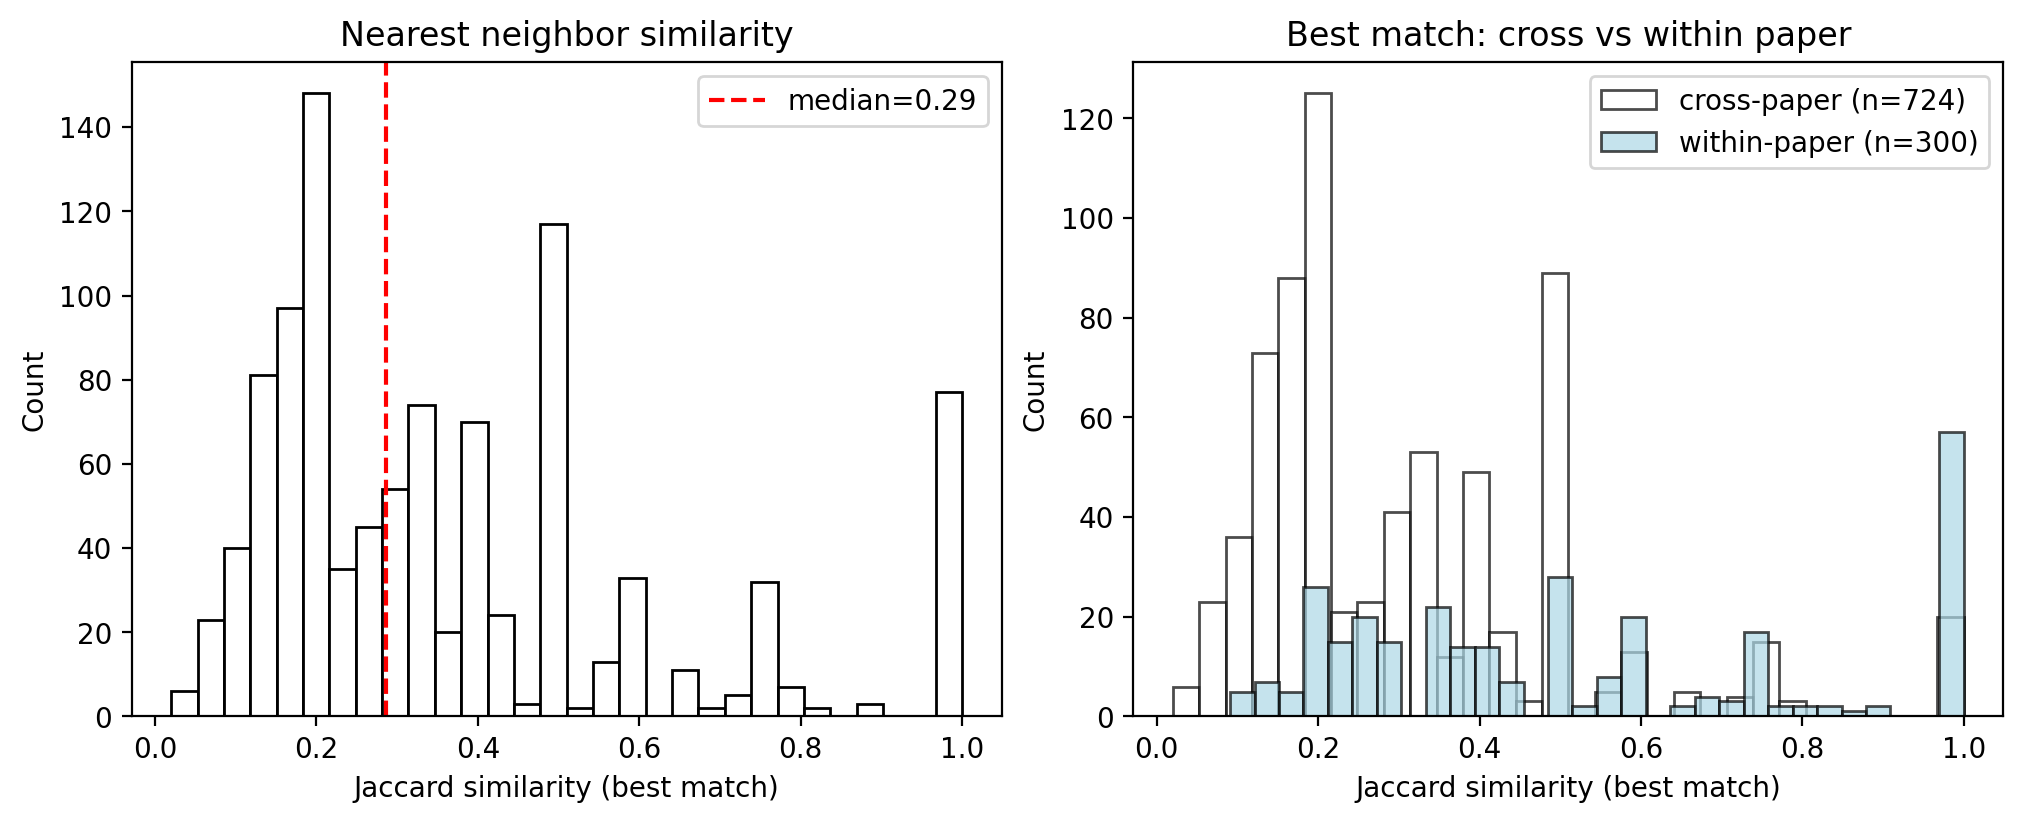

Best match is within same paper: 300 / 1024 (29.3%)
Best match is cross-paper:       724 / 1024 (70.7%)


In [7]:
# Take just the top-1 hit per profile
top1 = hits_df.sort_values("jaccard", ascending=False).drop_duplicates(subset=["idx_a"], keep="first")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax = axes[0]
ax.hist(top1["jaccard"], bins=30, edgecolor="k", facecolor="white")
ax.axvline(top1["jaccard"].median(), color="red", ls="--",
           label=f"median={top1['jaccard'].median():.2f}")
ax.set(xlabel="Jaccard similarity (best match)", ylabel="Count",
       title="Nearest neighbor similarity")
ax.legend()

ax = axes[1]
cross = top1[~top1["same_paper"]]
within = top1[top1["same_paper"]]
ax.hist(cross["jaccard"], bins=30, edgecolor="k", facecolor="white",
        alpha=0.7, label=f"cross-paper (n={len(cross)})")
ax.hist(within["jaccard"], bins=30, edgecolor="k", facecolor="lightblue",
        alpha=0.7, label=f"within-paper (n={len(within)})")
ax.set(xlabel="Jaccard similarity (best match)", ylabel="Count",
       title="Best match: cross vs within paper")
ax.legend()

plt.show()

print(f"Best match is within same paper: {len(within)} / {len(top1)} ({len(within)/len(top1)*100:.1f}%)")
print(f"Best match is cross-paper:       {len(cross)} / {len(top1)} ({len(cross)/len(top1)*100:.1f}%)")

## Cross-paper matches: different names, similar genes

These are the most interesting cases — cell types from different papers that share
marker genes but have different names. Candidates for harmonization.

In [8]:
# Cross-paper, different name, high Jaccard
cross_diff = hits_df[(~hits_df["same_paper"]) & (~hits_df["same_name"])].copy()
cross_diff = cross_diff.sort_values("jaccard", ascending=False)

# Deduplicate (a,b) and (b,a)
cross_diff["pair_key"] = cross_diff.apply(
    lambda r: tuple(sorted([(r["paper_a"], r["celltype_a"]),
                             (r["paper_b"], r["celltype_b"])])),
    axis=1
)
cross_diff_dedup = cross_diff.drop_duplicates(subset=["pair_key"], keep="first")

print(f"Cross-paper, different-name pairs with Jaccard > 0: {len(cross_diff_dedup):,}")
print(f"Pairs with Jaccard >= 0.5: {(cross_diff_dedup['jaccard'] >= 0.5).sum()}")
print(f"Pairs with Jaccard >= 0.3: {(cross_diff_dedup['jaccard'] >= 0.3).sum()}")
print()

Cross-paper, different-name pairs with Jaccard > 0: 5,431
Pairs with Jaccard >= 0.5: 182
Pairs with Jaccard >= 0.3: 651



In [9]:
# Show top cross-paper different-name matches with shared genes
def show_match(row):
    gs_a = filtered[(row["paper_a"], row["celltype_a"])]
    gs_b = filtered[(row["paper_b"], row["celltype_b"])]
    shared = sorted(gs_a & gs_b)
    only_a = sorted(gs_a - gs_b)
    only_b = sorted(gs_b - gs_a)
    print(f"  {row['celltype_a']} ({row['paper_a'][:8]}...)")
    print(f"  {row['celltype_b']} ({row['paper_b'][:8]}...)")
    print(f"  Jaccard={row['jaccard']:.3f}  shared={row['n_shared']}  |A|={row['n_a']}  |B|={row['n_b']}")
    print(f"  Shared genes: {', '.join(shared)}")
    if only_a:
        print(f"  Only in A: {', '.join(only_a)}")
    if only_b:
        print(f"  Only in B: {', '.join(only_b)}")
    print()

print("Top 20 cross-paper matches with DIFFERENT names:\n")
for _, row in cross_diff_dedup.head(20).iterrows():
    show_match(row)

Top 20 cross-paper matches with DIFFERENT names:

  MESENCHYMAL STEM CELL (2439b48c...)
  HTDSCS (e78eaa01...)
  Jaccard=1.000  shared=3  |A|=3  |B|=3
  Shared genes: ENSG00000026508, ENSG00000106991, ENSG00000154096

  T CELL (8e460cfc...)
  T-CELL (307b2bd7...)
  Jaccard=1.000  shared=3  |A|=3  |B|=3
  Shared genes: ENSG00000167286, ENSG00000198851, ENSG00000289746

  TREG.1 (e2efdcad...)
  TN (96c0ca44...)
  Jaccard=1.000  shared=4  |A|=4  |B|=4
  Shared genes: ENSG00000081059, ENSG00000126353, ENSG00000138795, ENSG00000188404

  HUMAN PLURIPOTENT STEM CELL (0c7fdd53...)
  PLURIPOTENT (48122146...)
  Jaccard=1.000  shared=3  |A|=3  |B|=3
  Shared genes: ENSG00000111704, ENSG00000181449, ENSG00000204531

  TCM (96c0ca44...)
  TREG.1 (e2efdcad...)
  Jaccard=1.000  shared=4  |A|=4  |B|=4
  Shared genes: ENSG00000081059, ENSG00000126353, ENSG00000138795, ENSG00000188404

  FIBROBLAST (COL1A1) (d8ee72e2...)
  FIBROBLAST CLUSTERS (eda68d46...)
  Jaccard=1.000  shared=3  |A|=3  |B|=3
  Sha

## Cross-paper matches: same names, similar genes

Sanity check — cell types with the same name across papers should share markers.

In [10]:
# Cross-paper, same name
cross_same = hits_df[(~hits_df["same_paper"]) & (hits_df["same_name"])].copy()
cross_same = cross_same.sort_values("jaccard", ascending=False)
cross_same["pair_key"] = cross_same.apply(
    lambda r: tuple(sorted([(r["paper_a"], r["celltype_a"]),
                             (r["paper_b"], r["celltype_b"])])),
    axis=1
)
cross_same_dedup = cross_same.drop_duplicates(subset=["pair_key"], keep="first")

print(f"Cross-paper, same-name pairs: {len(cross_same_dedup):,}")
print(f"  Mean Jaccard:   {cross_same_dedup['jaccard'].mean():.3f}")
print(f"  Median Jaccard: {cross_same_dedup['jaccard'].median():.3f}")
print()

# Compare to different-name pairs
print(f"Cross-paper, different-name pairs: {len(cross_diff_dedup):,}")
print(f"  Mean Jaccard:   {cross_diff_dedup['jaccard'].mean():.3f}")
print(f"  Median Jaccard: {cross_diff_dedup['jaccard'].median():.3f}")

Cross-paper, same-name pairs: 120
  Mean Jaccard:   0.262
  Median Jaccard: 0.200

Cross-paper, different-name pairs: 5,431
  Mean Jaccard:   0.174
  Median Jaccard: 0.143


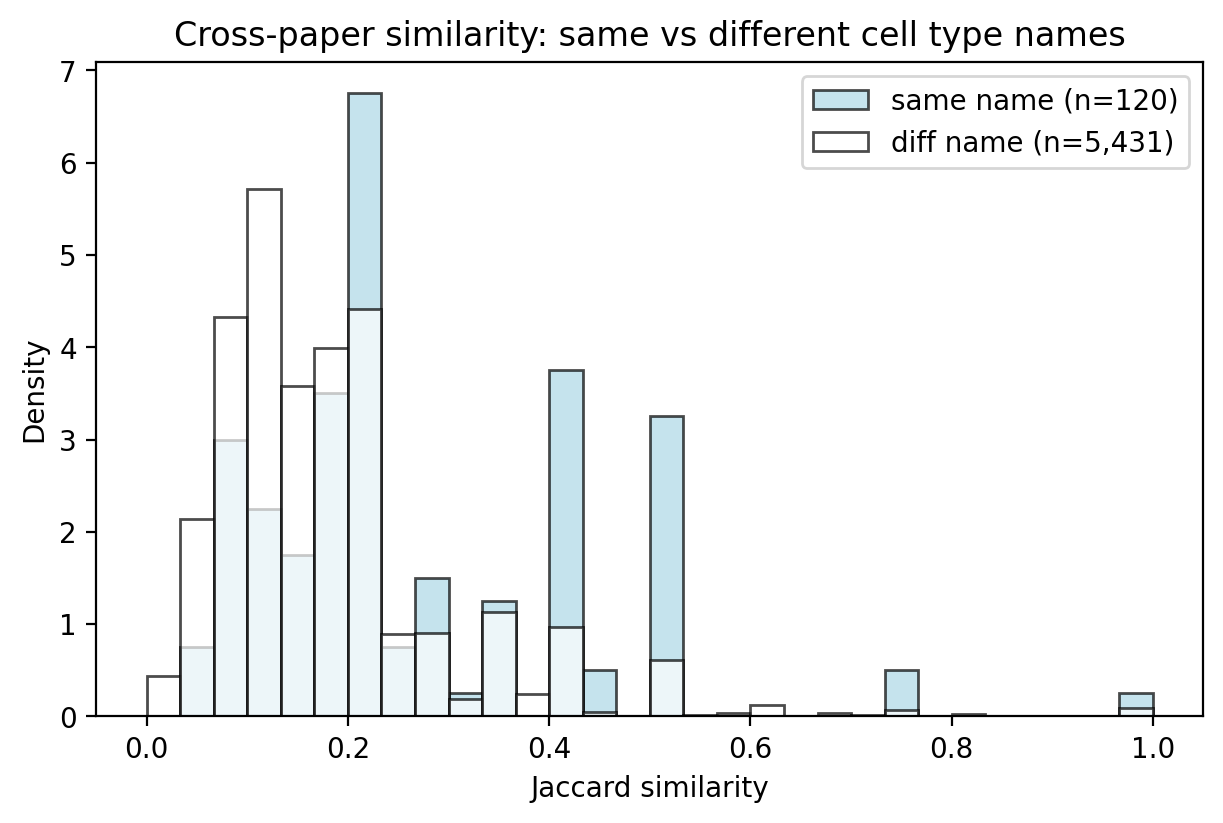

In [11]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

bins = np.linspace(0, 1, 31)
ax.hist(cross_same_dedup["jaccard"], bins=bins, edgecolor="k", facecolor="lightblue",
        alpha=0.7, label=f"same name (n={len(cross_same_dedup):,})", density=True)
ax.hist(cross_diff_dedup["jaccard"], bins=bins, edgecolor="k", facecolor="white",
        alpha=0.7, label=f"diff name (n={len(cross_diff_dedup):,})", density=True)
ax.set(xlabel="Jaccard similarity", ylabel="Density",
       title="Cross-paper similarity: same vs different cell type names")
ax.legend()
plt.show()

## Most connected cell types

Which cell type names appear most frequently in high-similarity cross-paper matches?

In [12]:
# For cross-paper pairs with Jaccard >= 0.3
high_sim = cross_diff_dedup[cross_diff_dedup["jaccard"] >= 0.3].copy()

# Count how often each cell type name participates
ct_counts = pd.concat([
    high_sim["celltype_a"].value_counts(),
    high_sim["celltype_b"].value_counts(),
]).groupby(level=0).sum().sort_values(ascending=False)

print(f"Cell types involved in cross-paper different-name matches (Jaccard >= 0.3): {len(ct_counts)}")
print()
print("Top 30:")
for ct, count in ct_counts.head(30).items():
    print(f"  {ct:<40} {count:>3} matches")

Cell types involved in cross-paper different-name matches (Jaccard >= 0.3): 301

Top 30:
  MONOCYTE                                  51 matches
  CD14+ MONOCYTE                            30 matches
  NAÏVE T CELL                              24 matches
  CYTOTOXIC                                 20 matches
  NK CELL                                   18 matches
  CD4+ T CELL                               15 matches
  NAIVE T CELLS OR TCMS                     15 matches
  T CELL                                    15 matches
  MONOCYTES                                 14 matches
  TCM                                       14 matches
  MONOCYTE-DERIVED CELL                     13 matches
  TN                                        13 matches
  CD4+ EM                                   12 matches
  BASAL2                                    12 matches
  CD4-CTLS                                  12 matches
  NK-DIM                                    12 matches
  MACROPHAGE                   

## Cell type alias groups

Build connected components of cell types linked by high Jaccard similarity.
Each component represents a group of cell type names that likely refer to the same
biological cell type.

In [13]:
from collections import deque

JACC_THRESHOLD = 0.4

# Build graph: nodes = cell type names, edges = high-Jaccard cross-paper different-name links
edges = cross_diff_dedup[cross_diff_dedup["jaccard"] >= JACC_THRESHOLD]

# Adjacency list on cell type names (not paper-specific)
adj = defaultdict(set)
edge_weights = {}
for _, r in edges.iterrows():
    a, b = r["celltype_a"], r["celltype_b"]
    adj[a].add(b)
    adj[b].add(a)
    pair = tuple(sorted([a, b]))
    if pair not in edge_weights or r["jaccard"] > edge_weights[pair]:
        edge_weights[pair] = r["jaccard"]

# BFS connected components
visited = set()
components = []
for node in adj:
    if node in visited:
        continue
    component = []
    queue = deque([node])
    while queue:
        curr = queue.popleft()
        if curr in visited:
            continue
        visited.add(curr)
        component.append(curr)
        for neighbor in adj[curr]:
            if neighbor not in visited:
                queue.append(neighbor)
    components.append(sorted(component))

# Sort by size
components.sort(key=len, reverse=True)

print(f"Alias groups (Jaccard >= {JACC_THRESHOLD}): {len(components)}")
print(f"Groups with 2+ names: {sum(1 for c in components if len(c) >= 2)}")
print(f"Groups with 3+ names: {sum(1 for c in components if len(c) >= 3)}")
print()
print("Largest alias groups:")
for i, comp in enumerate(components[:20]):
    print(f"  Group {i+1} ({len(comp)} names): {', '.join(comp[:8])}{'...' if len(comp) > 8 else ''}")

Alias groups (Jaccard >= 0.4): 43
Groups with 2+ names: 43
Groups with 3+ names: 22

Largest alias groups:
  Group 1 (25 names): ACTIVATED MEMORY CELL, ACTIVE NK CELL, ASTRO_S3, CD4-CTLS, CD8 T CELL, CD8+ T CELL, CD8+ T CELLS, CD8+ T-CELL...
  Group 2 (22 names): ACTIVATED NEUTROPHILS, AML BLAST, BASAL2, CD14+ MONOCYTE, CD34+ CD38+ CD123+ HAEMATOPOIETIC STEM AND PROGENITOR CELL, CDC2.1, CLUSTER 4, DYSFUNCTIONAL CD14 MONOCYTE...
  Group 3 (16 names): CD197⁺ IL2R/IL7R⁺ MONOCYTE, CD4.9, CD8.2, CEFX-SPECIFIC BRAIN METASTASIS-INFILTRATING PD-1+ CD8+ T CELL, CSF-UNEXPANDED T CELL, MAIT CELL, MEMORY, MEMORY CD4+ T CELL...
  Group 4 (16 names): BYSTANDER, CD4+ EM, CLASSICAL MONOCYTES, CLUSTER 0, CM, CORE ISGS, FIBRO-ADIPOGENIC PROGENITOR, HLA-DR-HIGH INTERMEDIATE MONOCYTES...
  Group 5 (12 names): CORE PLURIPOTENT POPULATION, EPI, HUMAN PLURIPOTENT STEM CELL, ICM, IPSC, NAÏVE HESC, NAÏVE HPSCS, PLURIPOTENT...
  Group 6 (12 names): CD4+ T CELL, CD4.10, CD8+ EXHAUSTED T CELL (TEXH), CD8+ PROLIFE

In [14]:
# Show detailed alias groups with shared genes
print("Detailed alias groups (top 10 by size):\n")
for i, comp in enumerate(components[:10]):
    print(f"=== Group {i+1}: {len(comp)} cell type names ===")
    for name in comp:
        # Collect all genes across all papers for this name
        all_genes = set()
        n_papers = 0
        for k, v in filtered.items():
            if k[1] == name:
                all_genes.update(v)
                n_papers += 1
        print(f"  {name} ({n_papers} paper{'s' if n_papers > 1 else ''}): {', '.join(sorted(all_genes)[:10])}{'...' if len(all_genes) > 10 else ''}")
    print()

Detailed alias groups (top 10 by size):

=== Group 1: 25 cell type names ===
  ACTIVATED MEMORY CELL (1 paper): ENSG00000100450, ENSG00000100453, ENSG00000111537, ENSG00000115523, ENSG00000145649
  ACTIVE NK CELL (1 paper): ENSG00000111537, ENSG00000180644, ENSG00000204490
  ASTRO_S3 (1 paper): ENSG00000026508, ENSG00000041982, ENSG00000131095
  CD4-CTLS (1 paper): ENSG00000100450, ENSG00000100453, ENSG00000105374, ENSG00000115523, ENSG00000145649, ENSG00000180644, ENSG00000197540
  CD8 T CELL (2 papers): ENSG00000073861, ENSG00000100453, ENSG00000111537, ENSG00000128016, ENSG00000157514, ENSG00000180644, ENSG00000187118, ENSG00000198888, ENSG00000215788
  CD8+ T CELL (4 papers): ENSG00000010810, ENSG00000028137, ENSG00000067182, ENSG00000089692, ENSG00000099860, ENSG00000105374, ENSG00000110848, ENSG00000113088, ENSG00000115085, ENSG00000115232...
  CD8+ T CELLS (1 paper): ENSG00000100453, ENSG00000111537, ENSG00000180644
  CD8+ T-CELL (1 paper): ENSG00000113088, ENSG00000153563, ENSG

## Cluster quality: within vs between cohesion

For binary marker gene vectors, we measure cluster quality using Jaccard similarity:
- **Within-cluster cohesion**: mean pairwise Jaccard among all profiles in the same cluster
- **Between-cluster separation**: mean pairwise Jaccard between profiles in different clusters
- **Silhouette score**: (b - a) / max(a, b) where a = mean Jaccard distance within cluster, b = mean Jaccard distance to nearest other cluster. Uses Jaccard distance = 1 - Jaccard similarity.

In [15]:
# Assign profiles to clusters based on cell type name membership
name_to_cluster = {}
for ci, comp in enumerate(components):
    for name in comp:
        name_to_cluster[name] = ci

# Group filtered profiles by cluster
cluster_to_profiles = defaultdict(list)  # cluster_id -> list of gene sets
unclustered_gsets = []

for k in keys:
    paper_id, ct = k
    genes = filtered[k]
    if ct in name_to_cluster:
        cluster_to_profiles[name_to_cluster[ct]].append(genes)
    else:
        unclustered_gsets.append(genes)

n_clustered = sum(len(v) for v in cluster_to_profiles.values())
print(f"Profiles in clusters: {n_clustered}")
print(f"Unclustered profiles: {len(unclustered_gsets)}")
print(f"Clusters with profiles: {len(cluster_to_profiles)}")

# --- Within-cluster mean Jaccard ---
def mean_pairwise_jaccard(gene_sets):
    if len(gene_sets) < 2:
        return float('nan')
    total = 0
    count = 0
    for i in range(len(gene_sets)):
        for j in range(i + 1, len(gene_sets)):
            inter = len(gene_sets[i] & gene_sets[j])
            union = len(gene_sets[i] | gene_sets[j])
            total += inter / union if union > 0 else 0
            count += 1
    return total / count

within_rows = []
for ci in sorted(cluster_to_profiles.keys()):
    gsets = cluster_to_profiles[ci]
    wj = mean_pairwise_jaccard(gsets)
    within_rows.append({
        'cluster_id': ci,
        'n_names': len(components[ci]),
        'n_profiles': len(gsets),
        'within_jaccard': wj,
        'names': ', '.join(components[ci][:5]) + ('...' if len(components[ci]) > 5 else ''),
    })

within_df = pd.DataFrame(within_rows)
within_df = within_df[within_df['n_profiles'] >= 2].copy()

print(f"\n--- Within-cluster Jaccard ({len(within_df)} clusters with 2+ profiles) ---")
print(f"  Mean:   {within_df['within_jaccard'].mean():.3f}")
print(f"  Median: {within_df['within_jaccard'].median():.3f}")

# --- Between-cluster mean Jaccard ---
cluster_ids = sorted(cluster_to_profiles.keys())
between_per_pair = []
for i in range(len(cluster_ids)):
    for j in range(i + 1, len(cluster_ids)):
        ci, cj = cluster_ids[i], cluster_ids[j]
        gi_list = cluster_to_profiles[ci]
        gj_list = cluster_to_profiles[cj]
        total = 0
        count = 0
        for gi in gi_list:
            for gj in gj_list:
                inter = len(gi & gj)
                union = len(gi | gj)
                total += inter / union if union > 0 else 0
                count += 1
        between_per_pair.append({
            'ci': ci, 'cj': cj,
            'mean_jaccard': total / count if count > 0 else 0,
        })

between_df = pd.DataFrame(between_per_pair)
mean_between = between_df['mean_jaccard'].mean()
print(f"\n--- Between-cluster Jaccard ({len(between_df)} cluster pairs) ---")
print(f"  Mean:   {mean_between:.4f}")
print(f"  Median: {between_df['mean_jaccard'].median():.4f}")

# --- Random baseline: mean Jaccard between random unclustered profiles ---
if len(unclustered_gsets) >= 100:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(unclustered_gsets), size=min(500, len(unclustered_gsets)), replace=False)
    sample = [unclustered_gsets[i] for i in idx]
    baseline_j = mean_pairwise_jaccard(sample)
    print(f"\n--- Random baseline (unclustered profile pairs) ---")
    print(f"  Mean Jaccard: {baseline_j:.4f}")

# --- Summary ---
mean_within = within_df['within_jaccard'].mean()
print(f"\n=== Cluster quality ===")
print(f"  Within / Between ratio: {mean_within / mean_between:.1f}x")
print(f"  Within - Between:       {mean_within - mean_between:.3f}")

Profiles in clusters: 351
Unclustered profiles: 688
Clusters with profiles: 43

--- Within-cluster Jaccard (43 clusters with 2+ profiles) ---
  Mean:   0.346
  Median: 0.375

--- Between-cluster Jaccard (903 cluster pairs) ---
  Mean:   0.0036
  Median: 0.0000



--- Random baseline (unclustered profile pairs) ---
  Mean Jaccard: 0.0019

=== Cluster quality ===
  Within / Between ratio: 95.1x
  Within - Between:       0.342


In [16]:
# Silhouette score using Jaccard distance (1 - Jaccard)
# For each profile in a cluster, compute:
#   a(i) = mean Jaccard distance to all other profiles in same cluster
#   b(i) = min over other clusters of mean Jaccard distance to profiles in that cluster
#   s(i) = (b(i) - a(i)) / max(a(i), b(i))

# Only use clusters with 2+ profiles
valid_clusters = [ci for ci in cluster_ids if len(cluster_to_profiles[ci]) >= 2]

silhouette_scores = []
for ci in valid_clusters:
    gsets_ci = cluster_to_profiles[ci]
    for pi in range(len(gsets_ci)):
        gs = gsets_ci[pi]

        # a(i): mean distance to same-cluster profiles
        dists_within = []
        for pj in range(len(gsets_ci)):
            if pi == pj:
                continue
            inter = len(gs & gsets_ci[pj])
            union = len(gs | gsets_ci[pj])
            dists_within.append(1 - (inter / union if union > 0 else 0))
        a_i = np.mean(dists_within)

        # b(i): min mean distance to any other cluster
        b_i = float('inf')
        for cj in valid_clusters:
            if cj == ci:
                continue
            gsets_cj = cluster_to_profiles[cj]
            dists_between = []
            for gj in gsets_cj:
                inter = len(gs & gj)
                union = len(gs | gj)
                dists_between.append(1 - (inter / union if union > 0 else 0))
            mean_dist = np.mean(dists_between)
            b_i = min(b_i, mean_dist)

        denom = max(a_i, b_i)
        s_i = (b_i - a_i) / denom if denom > 0 else 0
        silhouette_scores.append({
            'cluster_id': ci,
            'silhouette': s_i,
            'a_i': a_i,
            'b_i': b_i,
        })

sil_df = pd.DataFrame(silhouette_scores)
print(f"Silhouette scores (Jaccard distance) for {len(sil_df)} clustered profiles")
print(f"  Mean:   {sil_df['silhouette'].mean():.3f}")
print(f"  Median: {sil_df['silhouette'].median():.3f}")
print(f"  Std:    {sil_df['silhouette'].std():.3f}")
print(f"  Range:  [{sil_df['silhouette'].min():.3f}, {sil_df['silhouette'].max():.3f}]")
print()

# Per-cluster mean silhouette
cluster_sil = sil_df.groupby('cluster_id')['silhouette'].mean().reset_index()
cluster_sil.columns = ['cluster_id', 'mean_silhouette']
cluster_sil = cluster_sil.merge(within_df[['cluster_id', 'n_names', 'n_profiles', 'within_jaccard', 'names']], on='cluster_id')
cluster_sil = cluster_sil.sort_values('mean_silhouette', ascending=False)

print("Per-cluster mean silhouette (top 15):")
for _, r in cluster_sil.head(15).iterrows():
    print(f"  sil={r['mean_silhouette']:+.3f}  within_J={r['within_jaccard']:.3f}"
          f"  ({r['n_profiles']:>3} profiles, {r['n_names']:>2} names)  {r['names']}")
print()
print("Per-cluster mean silhouette (bottom 10):")
for _, r in cluster_sil.tail(10).iterrows():
    print(f"  sil={r['mean_silhouette']:+.3f}  within_J={r['within_jaccard']:.3f}"
          f"  ({r['n_profiles']:>3} profiles, {r['n_names']:>2} names)  {r['names']}")

Silhouette scores (Jaccard distance) for 351 clustered profiles


  Mean:   0.138
  Median: 0.119
  Std:    0.204
  Range:  [-0.311, 1.000]

Per-cluster mean silhouette (top 15):
  sil=+1.000  within_J=1.000  (  2 profiles,  2 names)  FIBROBLAST (COL1A1), FIBROBLAST CLUSTERS
  sil=+0.663  within_J=0.714  (  2 profiles,  2 names)  ASC, PC
  sil=+0.600  within_J=0.667  (  3 profiles,  3 names)  ANTIBODY-SECRETING CELL, B MATURE, B REGULATORY
  sil=+0.554  within_J=0.571  (  6 profiles,  5 names)  CD56DIM NK CELL, CYTOTOXIC NK CELL, PRE-CYTOTOXIC NK CELL, REGULATORY NK CELL, TOLERANT NK CELL
  sil=+0.533  within_J=0.533  (  3 profiles,  3 names)  ISC, MIX_2, STEM CELL
  sil=+0.485  within_J=0.500  (  2 profiles,  2 names)  SKIN CUTANEOUS MELANOMA, SUBCLASS B
  sil=+0.466  within_J=0.500  (  2 profiles,  2 names)  SERTOLI CELLS, SERTOLI INTERSTITIAL PRECURSOR CELL
  sil=+0.455  within_J=0.479  (  6 profiles,  6 names)  HTDSC, HTDSCS, IMSC, IMSCS, MESENCHYMAL STEM CELL...
  sil=+0.444  within_J=0.462  (  2 profiles,  2 names)  MAC.5, TAM_ISG15
  sil=+0.4

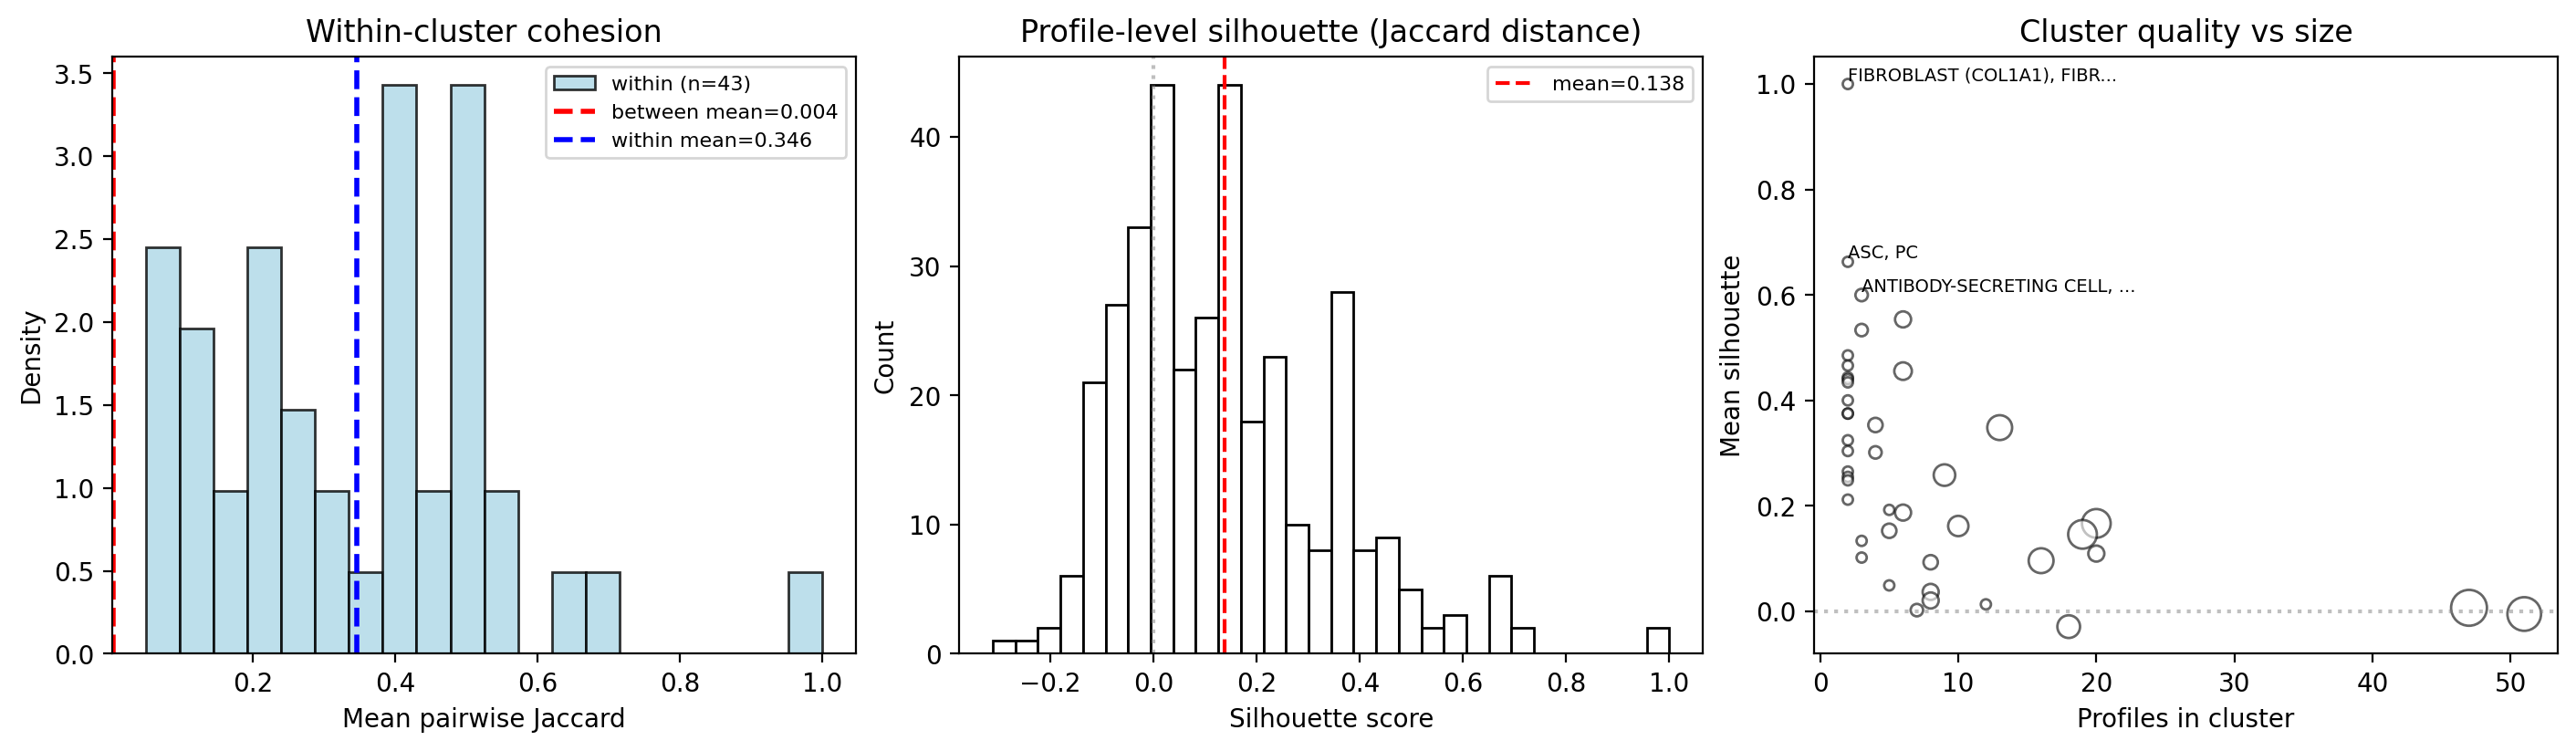

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

# 1. Within vs between Jaccard per cluster
ax = axes[0]
ax.hist(within_df['within_jaccard'], bins=20, edgecolor='k', facecolor='lightblue',
        alpha=0.8, label=f'within (n={len(within_df)})', density=True)
ax.axvline(mean_between, color='red', ls='--', lw=2,
           label=f'between mean={mean_between:.3f}')
ax.axvline(within_df['within_jaccard'].mean(), color='blue', ls='--', lw=2,
           label=f'within mean={within_df["within_jaccard"].mean():.3f}')
ax.set(xlabel='Mean pairwise Jaccard', ylabel='Density',
       title='Within-cluster cohesion')
ax.legend(fontsize=8)

# 2. Silhouette distribution
ax = axes[1]
ax.hist(sil_df['silhouette'], bins=30, edgecolor='k', facecolor='white')
ax.axvline(sil_df['silhouette'].mean(), color='red', ls='--',
           label=f"mean={sil_df['silhouette'].mean():.3f}")
ax.axvline(0, color='gray', ls=':', alpha=0.5)
ax.set(xlabel='Silhouette score', ylabel='Count',
       title='Profile-level silhouette (Jaccard distance)')
ax.legend(fontsize=8)

# 3. Per-cluster silhouette vs cluster size
ax = axes[2]
ax.scatter(cluster_sil['n_profiles'], cluster_sil['mean_silhouette'],
           s=cluster_sil['n_names'] * 8, alpha=0.6, edgecolor='k', facecolor='white')
ax.axhline(0, color='gray', ls=':', alpha=0.5)
ax.set(xlabel='Profiles in cluster', ylabel='Mean silhouette',
       title='Cluster quality vs size')
# Annotate a few
for _, r in cluster_sil.head(3).iterrows():
    short = r['names'][:25] + '...' if len(r['names']) > 25 else r['names']
    ax.annotate(short, (r['n_profiles'], r['mean_silhouette']),
                fontsize=7, ha='left', va='bottom')

plt.show()

## Mega cluster breakdown

The largest alias cluster (58 names, 120 profiles) has a silhouette near zero,
suggesting it merged heterogeneous cell types through transitive linkage. Apply
hierarchical clustering within this cluster to see if meaningful sub-groups emerge.

In [18]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# Get mega cluster (cluster 0 = largest)
mega_ci = 0
mega_names = set(components[mega_ci])

# Collect all profiles in mega cluster with labels
mega_profiles = []
for k in keys:
    paper_id, ct = k
    if ct in mega_names:
        mega_profiles.append((paper_id, ct, filtered[k]))

n_mega = len(mega_profiles)
print(f"Mega cluster: {len(mega_names)} names, {n_mega} profiles")

# Pairwise Jaccard distance matrix
dist_mat = np.zeros((n_mega, n_mega))
for i in range(n_mega):
    for j in range(i + 1, n_mega):
        gs_i = mega_profiles[i][2]
        gs_j = mega_profiles[j][2]
        inter = len(gs_i & gs_j)
        union = len(gs_i | gs_j)
        dist = 1 - (inter / union if union > 0 else 0)
        dist_mat[i, j] = dist
        dist_mat[j, i] = dist

# Hierarchical clustering (average linkage)
condensed = squareform(dist_mat)
Z = linkage(condensed, method='average')

# Cut at a few thresholds to see sub-cluster structure
for t in [0.7, 0.8, 0.9, 0.95]:
    labels = fcluster(Z, t=t, criterion='distance')
    n_sub = len(set(labels))
    sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
    print(f"\nCut at distance {t}: {n_sub} sub-clusters")
    print(f"  Sizes: {', '.join(str(s) for s in sizes.values[:15])}{'...' if len(sizes) > 15 else ''}")

Mega cluster: 25 names, 47 profiles

Cut at distance 0.7: 24 sub-clusters
  Sizes: 9, 6, 4, 3, 3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1...

Cut at distance 0.8: 21 sub-clusters
  Sizes: 14, 10, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1...

Cut at distance 0.9: 18 sub-clusters
  Sizes: 24, 4, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1...

Cut at distance 0.95: 16 sub-clusters
  Sizes: 28, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1...


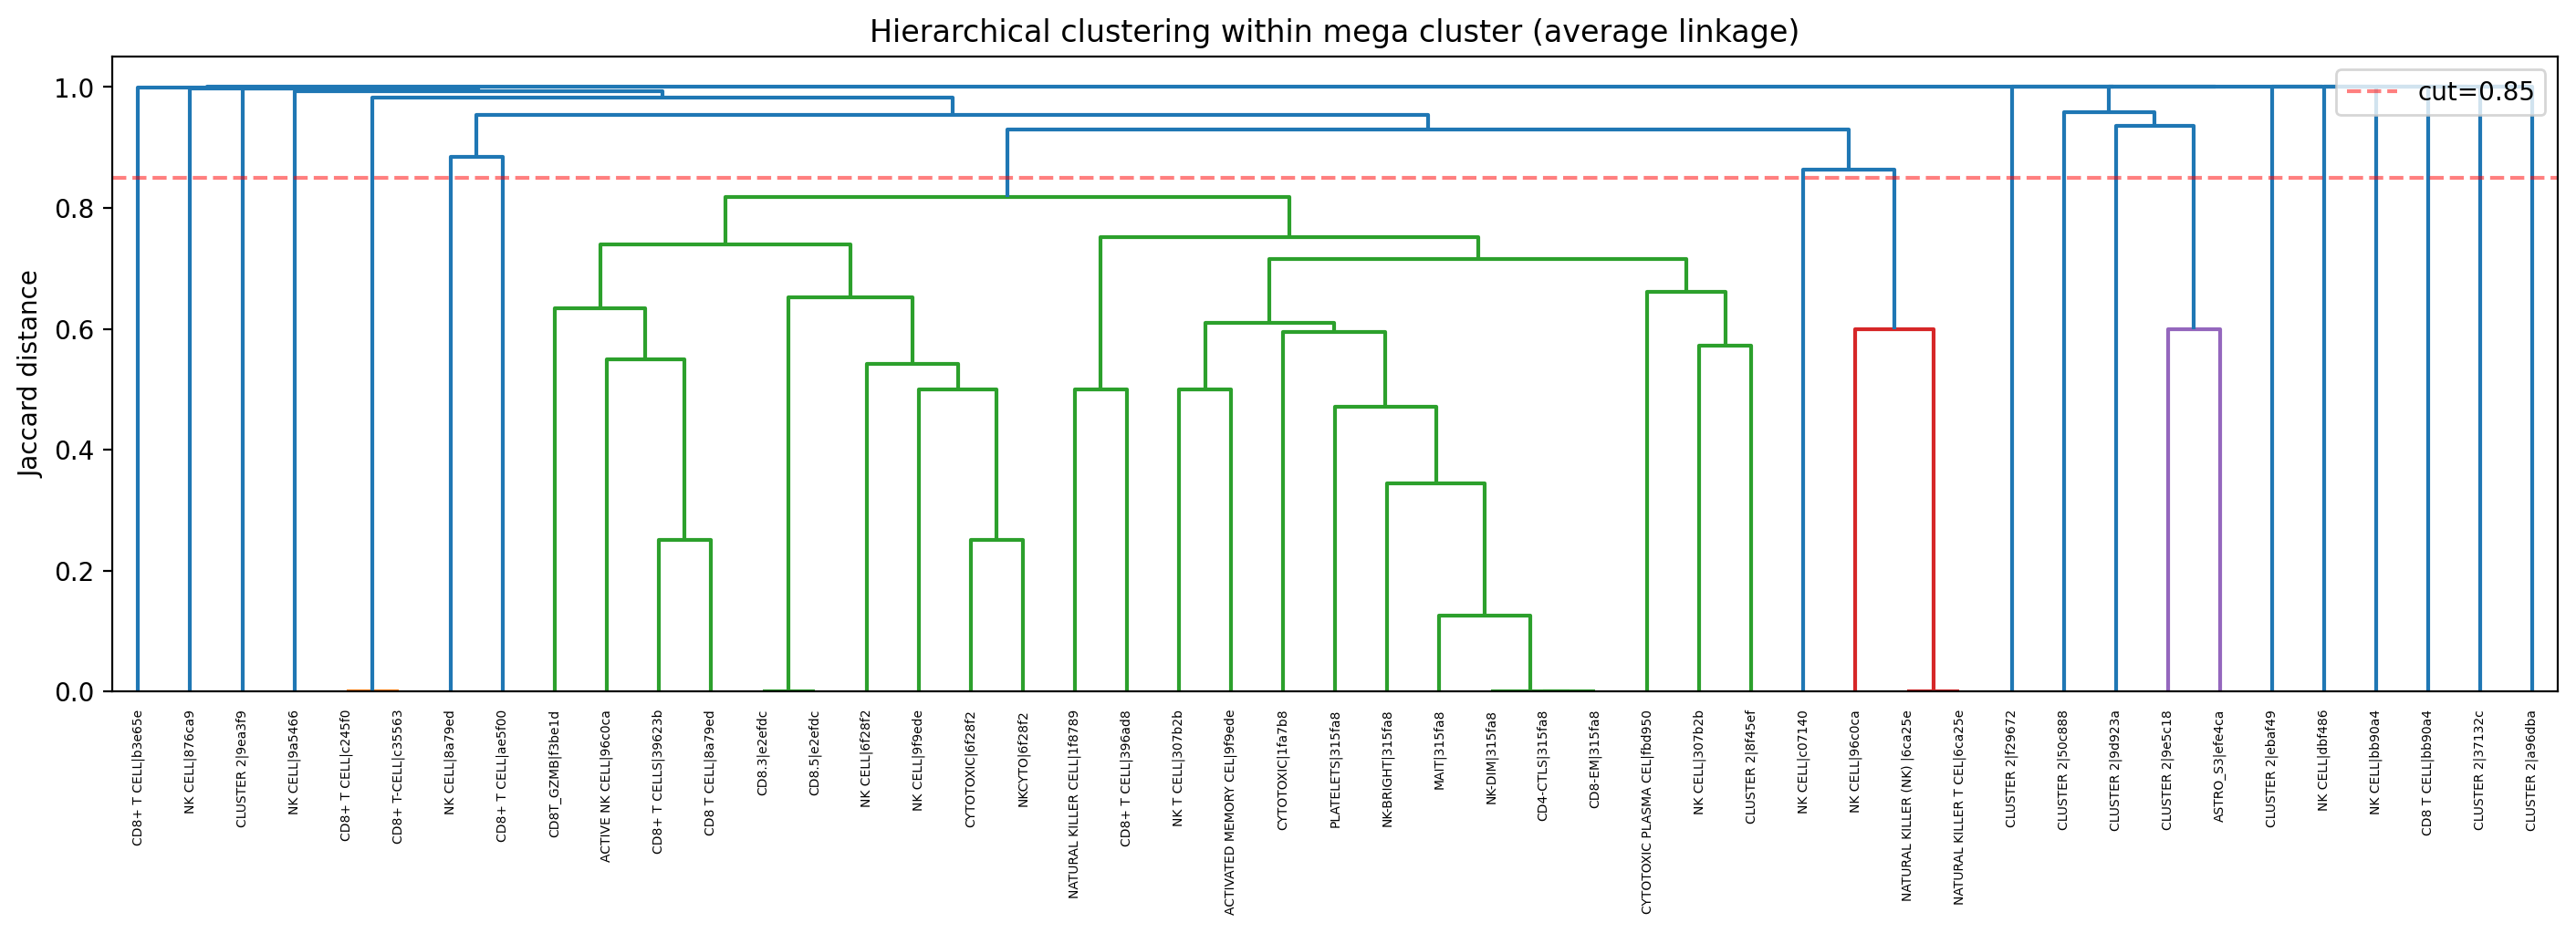

In [19]:
# Dendrogram
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

# Use cell type names as labels (truncated)
labels_short = [f"{ct[:20]}|{pid[:6]}" for pid, ct, _ in mega_profiles]

dendro = dendrogram(Z, labels=labels_short, ax=ax, leaf_rotation=90,
                    leaf_font_size=5, color_threshold=0.85)
ax.axhline(0.85, color='red', ls='--', alpha=0.5, label='cut=0.85')
ax.set(ylabel='Jaccard distance', title='Hierarchical clustering within mega cluster (average linkage)')
ax.legend()
plt.show()

In [20]:
# Show sub-clusters at a chosen cut
CUT_DIST = 0.85
sub_labels = fcluster(Z, t=CUT_DIST, criterion='distance')

# Group profiles by sub-cluster
sub_clusters = defaultdict(list)
for i, lab in enumerate(sub_labels):
    pid, ct, gs = mega_profiles[i]
    sub_clusters[lab].append((pid, ct, gs))

# Sort by size
sub_sorted = sorted(sub_clusters.items(), key=lambda x: -len(x[1]))

print(f"Sub-clusters at distance {CUT_DIST}: {len(sub_sorted)}")
sizes = [len(v) for _, v in sub_sorted]
print(f"Sizes: {sizes}\n")

for lab, members in sub_sorted:
    if len(members) < 2:
        continue
    # Unique names
    names = sorted(set(ct for _, ct, _ in members))
    gsets = [gs for _, _, gs in members]

    # Within sub-cluster Jaccard
    sub_j = mean_pairwise_jaccard(gsets)

    # Genes appearing in >= 40% of profiles
    from collections import Counter
    gene_freq = Counter()
    for gs in gsets:
        for g in gs:
            gene_freq[g] += 1
    core_genes = sorted([g for g, c in gene_freq.items() if c >= len(gsets) * 0.4],
                        key=lambda g: -gene_freq[g])

    names_str = ', '.join(names[:10])
    if len(names) > 10:
        names_str += '...'
    core_str = ', '.join(gene_display(g) for g in core_genes[:15]) if core_genes else 'none'

    print(f"--- Sub-cluster {lab} ({len(members)} profiles, {len(names)} names, within_J={sub_j:.3f}) ---")
    print(f"  Names: {names_str}")
    print(f"  Core genes (>40% of profiles): {core_str}")
    print()

Sub-clusters at distance 0.85: 20
Sizes: [24, 3, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- Sub-cluster 4 (24 profiles, 21 names, within_J=0.275) ---
  Names: ACTIVATED MEMORY CELL, ACTIVE NK CELL, CD4-CTLS, CD8 T CELL, CD8+ T CELL, CD8+ T CELLS, CD8-EM, CD8.3, CD8.5, CD8T_GZMB...
  Core genes (>40% of profiles): GNLY, PRF1, NKG7, GZMA, GZMB

--- Sub-cluster 5 (3 profiles, 3 names, within_J=0.600) ---
  Names: NATURAL KILLER (NK) CELL, NATURAL KILLER T CELL (NKT), NK CELL
  Core genes (>40% of profiles): CD94, CD56, GNLY

--- Sub-cluster 11 (2 profiles, 2 names, within_J=0.400) ---
  Names: ASTRO_S3, CLUSTER 2
  Core genes (>40% of profiles): GFAP, CD44, EGFR, SOX2, TNC

--- Sub-cluster 1 (2 profiles, 2 names, within_J=1.000) ---
  Names: CD8+ T CELL, CD8+ T-CELL
  Core genes (>40% of profiles): CD8B, CD8A, GZMK



### Per-profile silhouette scores within mega cluster

Compute silhouette scores for each profile within the mega cluster using the
sub-cluster labels from `fcluster`. This measures how well each profile fits its
assigned sub-cluster versus the nearest alternative sub-cluster:
- $s = +1$: well-separated from other sub-clusters
- $s \approx 0$: on the boundary between two sub-clusters
- $s < 0$: potentially misassigned

In [21]:
# Per-profile silhouette within the mega cluster sub-clustering
# Uses dist_mat and sub_labels from the cells above

# Bio labels for the 3 immune sub-clusters
bio_labels = {
    4: "Cytotoxic effectors",
    10: "NK cell",
    3: "CD8 T cell",
}

sub_cluster_profiles = defaultdict(list)  # sub_label -> list of (index, paper_id, ct, gene_set)
for i, lab in enumerate(sub_labels):
    pid, ct, gs = mega_profiles[i]
    sub_cluster_profiles[lab].append((i, pid, ct, gs))

# Only consider sub-clusters with 2+ profiles
valid_subs = [lab for lab, members in sub_cluster_profiles.items() if len(members) >= 2]

mega_sil_rows = []
for lab in valid_subs:
    members = sub_cluster_profiles[lab]
    for idx, pid, ct, gs in members:
        # a(i): mean Jaccard distance to same sub-cluster profiles
        dists_within = [dist_mat[idx, idx2] for idx2, _, _, _ in members if idx2 != idx]
        a_i = np.mean(dists_within)

        # b(i): min mean distance to any other sub-cluster
        b_i = float('inf')
        nearest_sub = None
        for other_lab in valid_subs:
            if other_lab == lab:
                continue
            other_dists = [dist_mat[idx, idx2] for idx2, _, _, _ in sub_cluster_profiles[other_lab]]
            mean_dist = np.mean(other_dists)
            if mean_dist < b_i:
                b_i = mean_dist
                nearest_sub = other_lab

        denom = max(a_i, b_i)
        s_i = (b_i - a_i) / denom if denom > 0 else 0

        gene_names = sorted(gene_display(g) for g in gs)
        mega_sil_rows.append({
            'sub_label': lab,
            'sub_name': bio_labels.get(lab, f'sub-{lab}'),
            'profile_idx': idx,
            'paper_id': pid,
            'cell_type': ct,
            'silhouette': s_i,
            'a_i': a_i,
            'b_i': b_i,
            'nearest_sub': nearest_sub,
            'nearest_sub_name': bio_labels.get(nearest_sub, f'sub-{nearest_sub}') if nearest_sub else None,
            'n_genes': len(gs),
            'genes': ', '.join(gene_names),
        })

mega_sil_df = pd.DataFrame(mega_sil_rows)

# Report for the 3 immune sub-clusters in the supplementary table
table_subs = [4, 10, 3]
table_sil_df = mega_sil_df[mega_sil_df['sub_label'].isin(table_subs)].copy()

for lab in table_subs:
    sub = table_sil_df[table_sil_df['sub_label'] == lab].sort_values('silhouette')
    name = bio_labels[lab]
    sils = sub['silhouette']
    print(f"=== {name} (sub-cluster {lab}, n={len(sub)}) ===")
    print(f"  Mean silhouette: {sils.mean():.3f}  Range: [{sils.min():.3f}, {sils.max():.3f}]")
    print()
    for _, r in sub.iterrows():
        nearest = r['nearest_sub_name'] or 'N/A'
        print(f"  s={r['silhouette']:+.3f}  a={r['a_i']:.3f}  b={r['b_i']:.3f}  "
              f"nearest={nearest:<25}  {r['cell_type']:<30} ({r['paper_id'][:8]}...)")
    print()

=== Cytotoxic effectors (sub-cluster 4, n=24) ===
  Mean silhouette: 0.194  Range: [-0.006, 0.382]

  s=-0.006  a=0.777  b=0.772  nearest=sub-5                      NK CELL                        (6f28f2e1...)
  s=+0.015  a=0.788  b=0.800  nearest=sub-1                      CD8+ T CELL                    (396ad855...)
  s=+0.055  a=0.816  b=0.863  nearest=sub-5                      NK CELL                        (307b2bd7...)
  s=+0.064  a=0.749  b=0.800  nearest=sub-5                      NK CELL                        (9f9eded3...)
  s=+0.077  a=0.800  b=0.867  nearest=sub-5                      NATURAL KILLER CELL            (1f87890c...)
  s=+0.116  a=0.786  b=0.889  nearest=sub-5                      NK T CELL                      (307b2bd7...)
  s=+0.130  a=0.870  b=1.000  nearest=sub-5                      ACTIVE NK CELL                 (96c0ca44...)
  s=+0.145  a=0.855  b=1.000  nearest=sub-5                      CLUSTER 2                      (8f45ef4c...)
  s=+0.153  a=0.766 

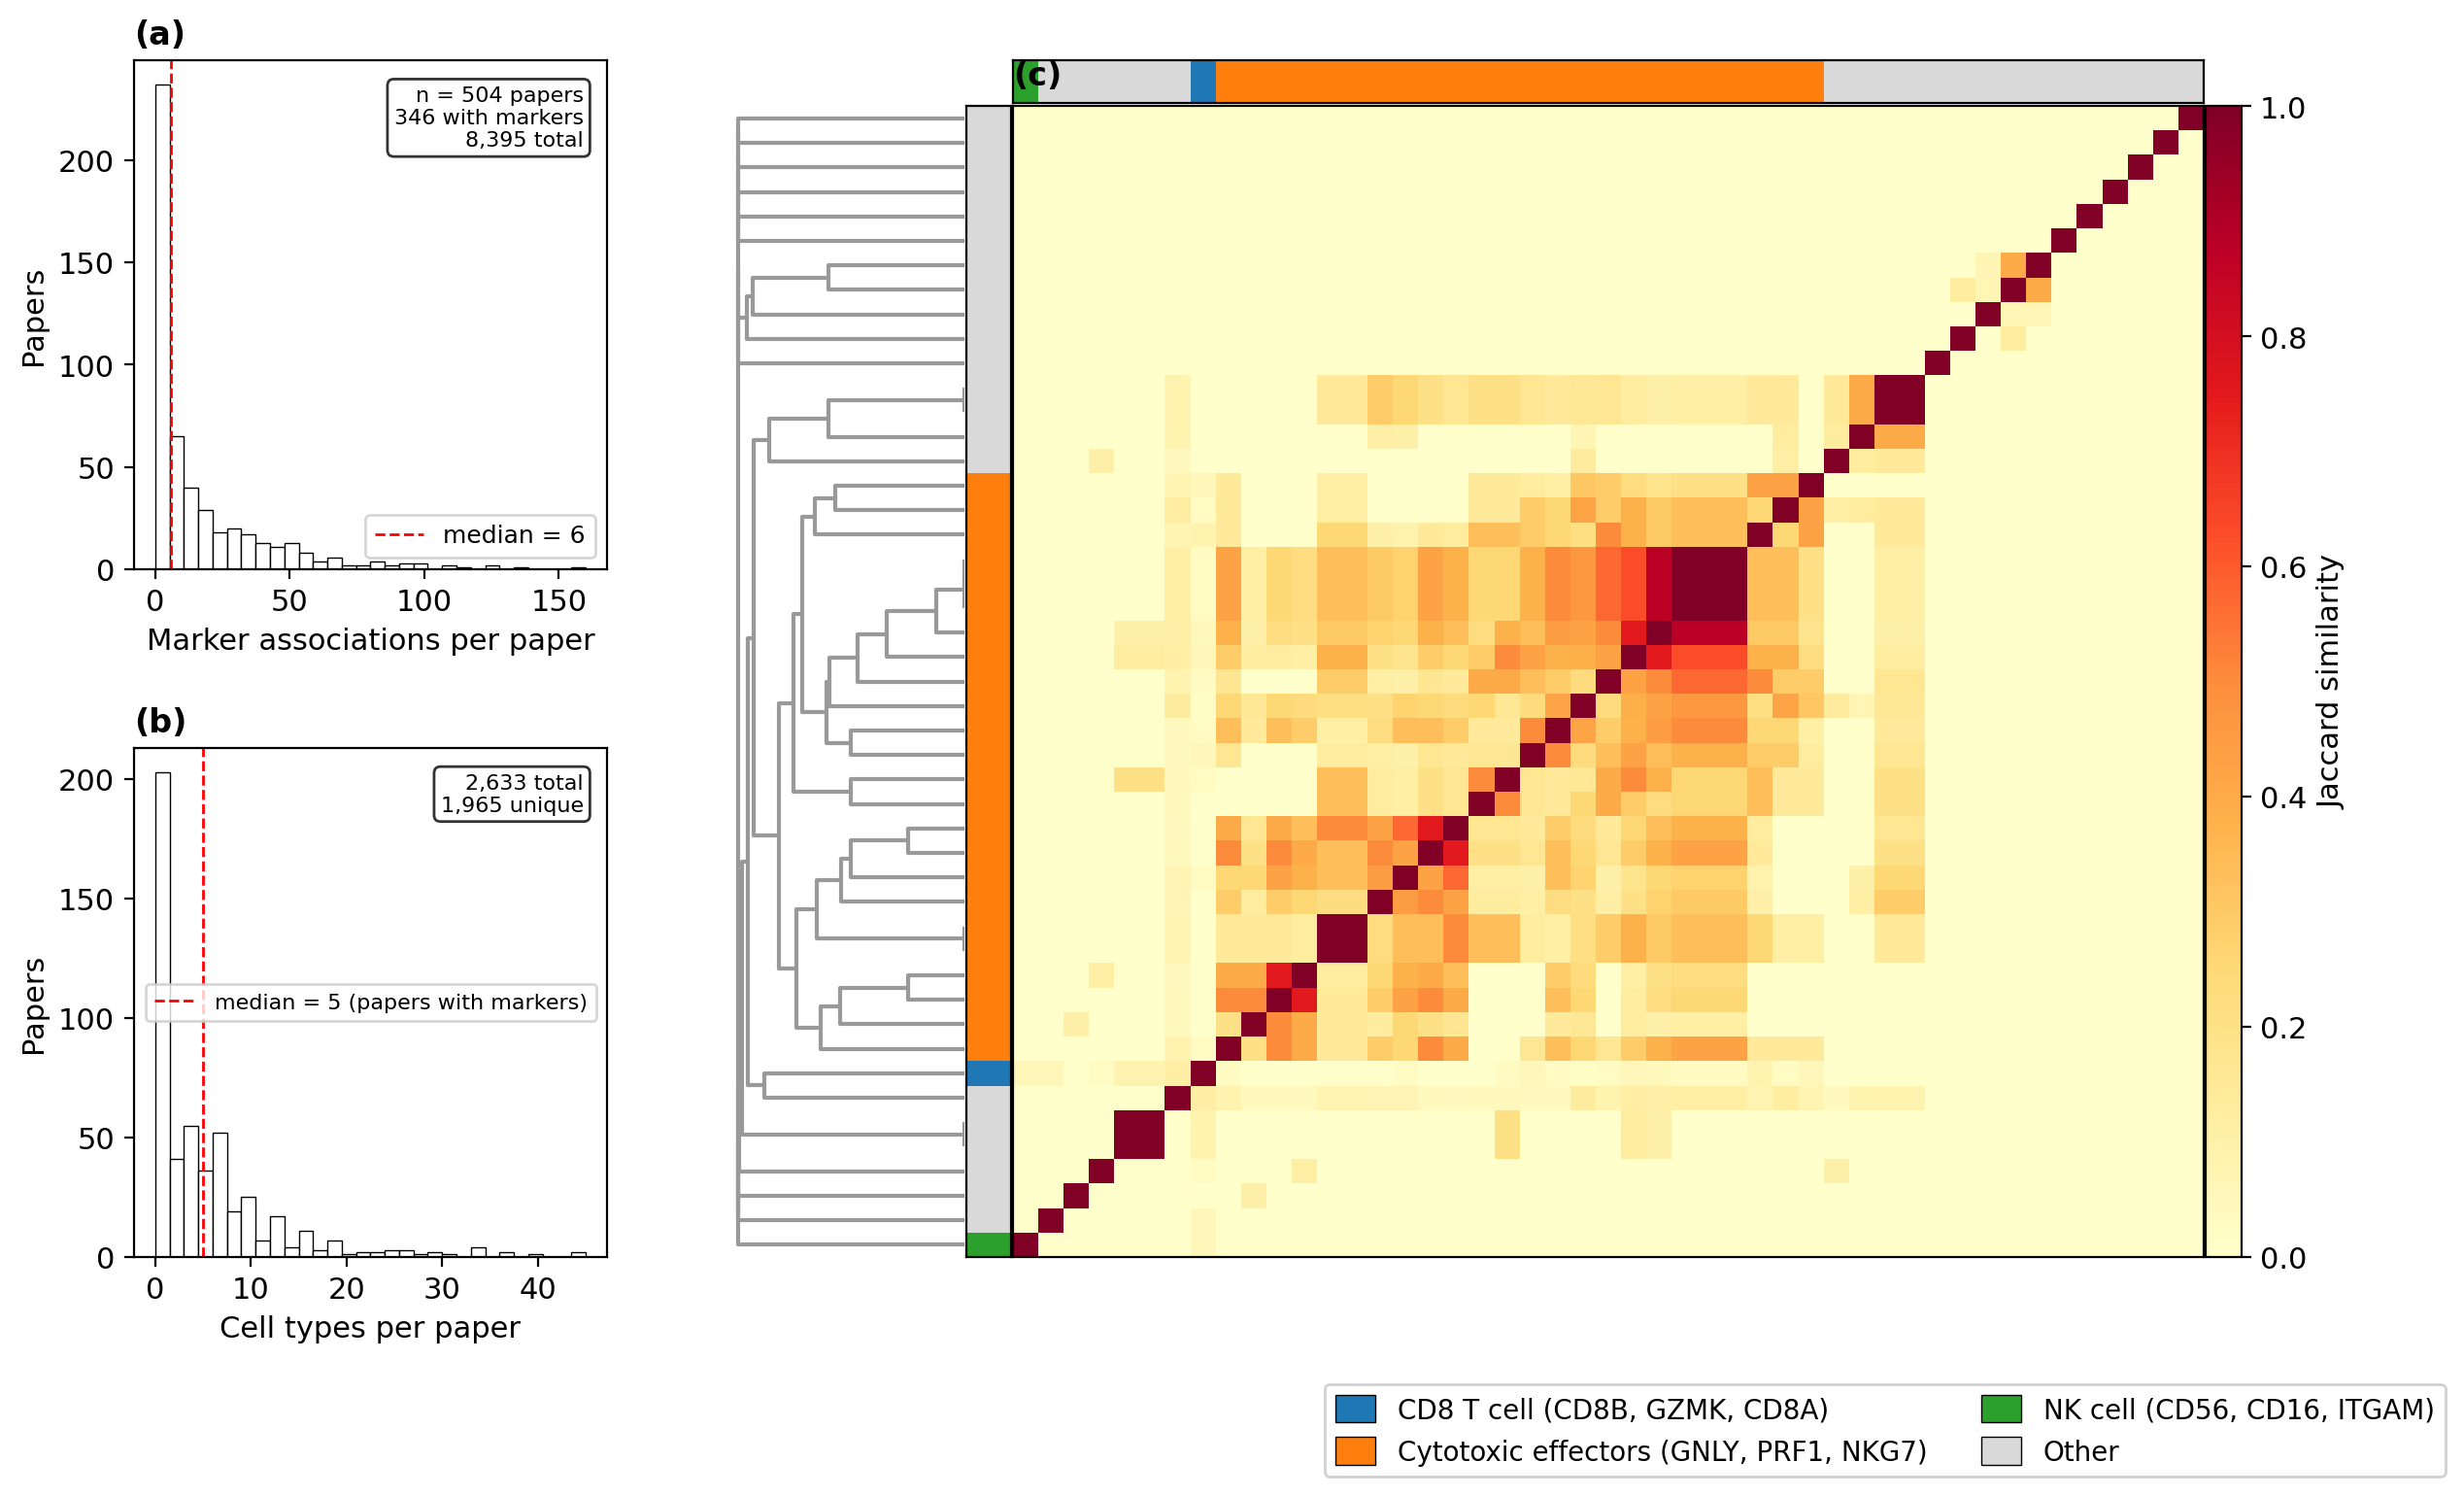

Saved to figures/


In [22]:
# Publication figure: (a,b) corpus descriptive stats + (c) dendrogram + heatmap

from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import dendrogram as dendro_plot

fsize = 11
plt.rcParams.update({"font.size": fsize})

# --- Compute descriptive stats (include all 504 papers, including 0-marker ones) ---
# Count papers with human markers
per_paper_assoc = records_df.groupby('paper_id').size()
per_paper_ct = records_df.groupby('paper_id')['cell_type'].nunique()

# Add papers with 0 human markers (folders in MECA_DIR not in records_df)
all_papers = sorted([f for f in os.listdir(MECA_DIR)
                     if os.path.isdir(os.path.join(MECA_DIR, f))
                     and os.path.exists(os.path.join(MECA_DIR, f, "markers.json"))])
for pid in all_papers:
    if pid not in per_paper_assoc.index:
        per_paper_assoc[pid] = 0
        per_paper_ct[pid] = 0

# --- Bio labels for sub-clusters (human-only mega cluster) ---
bio_labels = {
    4: "Cytotoxic effectors",
    10: "NK cell",
    3: "CD8 T cell",
}
bio_genes = {
    4: "GNLY, PRF1, NKG7",
    10: "CD56, CD16, ITGAM",
    3: "CD8B, GZMK, CD8A",
}
cmap_tab = plt.cm.tab10
sub_colors = {}
for i, lab in enumerate(sorted(bio_labels.keys())):
    sub_colors[lab] = cmap_tab(i)

# --- Similarity matrix and leaf order ---
sim_mat = 1 - dist_mat
n_leaves = n_mega
dendro_silent = dendro_plot(Z, no_plot=True)
leaf_order = dendro_silent['leaves']
sim_ordered = sim_mat[np.ix_(leaf_order, leaf_order)]

cluster_colors = []
for idx in leaf_order:
    lab = sub_labels[idx]
    if lab in bio_labels:
        cluster_colors.append(mcolors.to_rgba(sub_colors[lab]))
    else:
        cluster_colors.append(mcolors.to_rgba('#d9d9d9'))

y_lo, y_hi = 0, n_leaves * 10

# --- Figure ---
fig = plt.figure(figsize=(14, 8))

# Outer grid: [descriptive | heatmap_block]
outer_gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 3.2], wspace=0.12)

# Left column: two stacked panels
left_gs = outer_gs[0].subgridspec(2, 1, hspace=0.35)

# (a) Associations per paper
ax_a = fig.add_subplot(left_gs[0])
ax_a.hist(per_paper_assoc, bins=30, edgecolor='k', facecolor='white', linewidth=0.5)
ax_a.axvline(per_paper_assoc.median(), color='red', ls='--', lw=1,
             label=f'median = {per_paper_assoc.median():.0f}')
ax_a.set(xlabel='Marker associations per paper', ylabel='Papers')
ax_a.legend(fontsize=9)
ax_a.set_title('(a)', fontsize=fsize+1, loc='left', fontweight='bold')
n_with = (per_paper_assoc > 0).sum()
n_total_papers = len(per_paper_assoc)
ax_a.text(0.95, 0.95, f'n = {n_total_papers} papers\n'
          f'{n_with} with markers\n'
          f'{per_paper_assoc.sum():,} total',
          transform=ax_a.transAxes, ha='right', va='top', fontsize=8,
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# (b) Cell types per paper
ax_b = fig.add_subplot(left_gs[1])
ax_b.hist(per_paper_ct, bins=30, edgecolor='k', facecolor='white', linewidth=0.5)
ax_b.axvline(per_paper_ct[per_paper_ct > 0].median(), color='red', ls='--', lw=1,
             label=f'median = {per_paper_ct[per_paper_ct > 0].median():.0f} (papers with markers)')
ax_b.set(xlabel='Cell types per paper', ylabel='Papers')
ax_b.legend(fontsize=8)
ax_b.set_title('(b)', fontsize=fsize+1, loc='left', fontweight='bold')
ax_b.text(0.95, 0.95, f'{per_paper_ct.sum():,} total\n'
          f'{records_df["cell_type"].nunique():,} unique',
          transform=ax_b.transAxes, ha='right', va='top', fontsize=8,
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Right column: dendrogram + heatmap
right_gs = outer_gs[1].subgridspec(2, 4,
    width_ratios=[0.8, 0.15, 4, 0.12],
    height_ratios=[0.15, 4],
    wspace=0.005, hspace=0.005)

# Dendrogram
ax_dend = fig.add_subplot(right_gs[1, 0])
dendro_plot(Z, orientation='left', ax=ax_dend,
            color_threshold=0, above_threshold_color='#999999',
            link_color_func=lambda k: '#999999', no_labels=True)
ax_dend.set_xticks([])
ax_dend.set_yticks([])
for sp in ax_dend.spines.values():
    sp.set_visible(False)
ax_dend.set_ylim(y_lo, y_hi)

# Left color sidebar
ax_cL = fig.add_subplot(right_gs[1, 1])
cL_img = np.array(cluster_colors).reshape(-1, 1, 4)
ax_cL.imshow(cL_img, aspect='auto', interpolation='nearest',
             extent=[0, 1, y_lo, y_hi], origin='lower')
ax_cL.set_xticks([])
ax_cL.set_yticks([])
ax_cL.set_ylim(y_lo, y_hi)

# Top color sidebar
ax_cT = fig.add_subplot(right_gs[0, 2])
cT_img = np.array(cluster_colors).reshape(1, -1, 4)
ax_cT.imshow(cT_img, aspect='auto', interpolation='nearest',
             extent=[y_lo, y_hi, 0, 1])
ax_cT.set_xticks([])
ax_cT.set_yticks([])

# Heatmap
ax_hm = fig.add_subplot(right_gs[1, 2])
im = ax_hm.imshow(sim_ordered, cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=1.0, interpolation='nearest',
                   extent=[y_lo, y_hi, y_lo, y_hi], origin='lower')
ax_hm.set_xticks([])
ax_hm.set_yticks([])
ax_hm.set_xlim(y_lo, y_hi)
ax_hm.set_ylim(y_lo, y_hi)
ax_hm.set_title('(c)', fontsize=fsize+1, loc='left', fontweight='bold', pad=8)

# Colorbar
ax_cb = fig.add_subplot(right_gs[1, 3])
plt.colorbar(im, cax=ax_cb)
ax_cb.set_ylabel('Jaccard similarity', fontsize=fsize)

# Legend for sub-clusters
handles = [Patch(facecolor=sub_colors[l], edgecolor='k',
                 label=f"{bio_labels[l]} ({bio_genes[l]})", lw=0.5)
           for l in sorted(bio_labels.keys())]
handles.append(Patch(facecolor='#d9d9d9', edgecolor='k',
                     label='Other', lw=0.5))
fig.legend(handles=handles, fontsize=10, loc='lower right',
           ncol=2, bbox_to_anchor=(0.98, -0.04), framealpha=0.9,
           handlelength=1.5, handleheight=1.2)

# Save
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/biorxiv_immune_cluster.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/biorxiv_immune_cluster.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved to figures/")

## Same-name cross-paper consistency

For cell types that appear with the exact same name in multiple papers,
how consistent are their marker gene profiles?

In [23]:
# Group profiles by cell type name
name_to_profiles = defaultdict(list)
for (paper_id, ct), genes in filtered.items():
    name_to_profiles[ct].append((paper_id, genes))

# Only cell types appearing in 2+ papers
multi_paper_cts = {ct: profs for ct, profs in name_to_profiles.items() if len(profs) >= 2}

consistency_rows = []
for ct, profs in multi_paper_cts.items():
    jaccards = []
    for i in range(len(profs)):
        for j in range(i + 1, len(profs)):
            gs_i = profs[i][1]
            gs_j = profs[j][1]
            inter = len(gs_i & gs_j)
            union = len(gs_i | gs_j)
            jacc = inter / union if union > 0 else 0
            jaccards.append(jacc)
    consistency_rows.append({
        "cell_type": ct,
        "n_papers": len(profs),
        "mean_jaccard": np.mean(jaccards),
        "median_jaccard": np.median(jaccards),
        "max_jaccard": np.max(jaccards),
        "n_pairs": len(jaccards),
    })

consistency_df = pd.DataFrame(consistency_rows).sort_values("n_papers", ascending=False)
print(f"Cell types appearing in 2+ papers: {len(consistency_df)}")
print(f"Overall mean Jaccard (same name, cross-paper): {consistency_df['mean_jaccard'].mean():.3f}")
print()

print("Top 20 most frequent cell types and their cross-paper consistency:")
for _, r in consistency_df.head(20).iterrows():
    print(f"  {r['cell_type']:<35} {r['n_papers']:>3} papers  "
          f"mean_J={r['mean_jaccard']:.3f}  max_J={r['max_jaccard']:.3f}")

Cell types appearing in 2+ papers: 76
Overall mean Jaccard (same name, cross-paper): 0.083

Top 20 most frequent cell types and their cross-paper consistency:
  MONOCYTE                             15 papers  mean_J=0.065  max_J=0.750
  T CELL                               12 papers  mean_J=0.143  max_J=1.000
  B CELL                               10 papers  mean_J=0.080  max_J=0.400
  NK CELL                              10 papers  mean_J=0.033  max_J=0.444
  CLUSTER 2                             9 papers  mean_J=0.005  max_J=0.125
  CLUSTER 3                             6 papers  mean_J=0.004  max_J=0.056
  CLUSTER 4                             6 papers  mean_J=0.005  max_J=0.077
  ENDOTHELIAL CELL                      5 papers  mean_J=0.051  max_J=0.200
  CD4+ T CELL                           5 papers  mean_J=0.027  max_J=0.088
  MESENCHYMAL                           5 papers  mean_J=0.112  max_J=0.400
  PLASMA CELL                           5 papers  mean_J=0.103  max_J=0.500
  MAC

In [24]:
# Monocyte supplementary table: papers with "MONOCYTE" in cell type name (>= 3 markers)
monocyte_profiles = {}
for (paper_id, ct), genes in filtered.items():
    if "MONOCYTE" in ct:
        monocyte_profiles[(paper_id, ct)] = genes

# Deduplicate by paper (keep longest profile if multiple monocyte cell types per paper)
paper_to_best = {}
for (pid, ct), genes in monocyte_profiles.items():
    if pid not in paper_to_best or len(genes) > len(paper_to_best[pid][1]):
        paper_to_best[pid] = (ct, genes)

print(f"Papers with monocyte profiles (>= {MIN_MARKERS} markers): {len(paper_to_best)}")
print()

# Compute pairwise Jaccard among monocyte papers
mono_papers = sorted(paper_to_best.keys())
mono_jaccards = []
for i in range(len(mono_papers)):
    for j in range(i + 1, len(mono_papers)):
        gs_i = paper_to_best[mono_papers[i]][1]
        gs_j = paper_to_best[mono_papers[j]][1]
        inter = len(gs_i & gs_j)
        union = len(gs_i | gs_j)
        mono_jaccards.append(inter / union if union > 0 else 0)

print(f"Mean pairwise Jaccard among monocyte papers: {np.mean(mono_jaccards):.3f}")
print(f"Median: {np.median(mono_jaccards):.3f}")
print()

# List papers with their markers
print("Paper ID | Cell type | N markers | Marker genes")
print("-" * 80)
for pid in mono_papers:
    ct, genes = paper_to_best[pid]
    gene_names = sorted(gene_display(g) for g in genes)
    print(f"{pid[:12]}... | {ct:<20} | {len(genes):>3} | {', '.join(gene_names)}")

Papers with monocyte profiles (>= 3 markers): 29

Mean pairwise Jaccard among monocyte papers: 0.063
Median: 0.000

Paper ID | Cell type | N markers | Marker genes
--------------------------------------------------------------------------------
0a537c3c-6db... | MONOCYTE             |   6 | CXCL8, EGR1, FCN1, JAK2, NFKBIZ, TNFAIP3
1e0a6787-73c... | ISG+ AP1LOW CLASSICAL MONOCYTES |   5 | IFI44L, IFI6, ISG15, MX1, MX2
1efd9fbe-6f0... | MONOCYTE             |   6 | BCL2, CD14, CD25, CD274, IL3RA, IL7R
1f87890c-7e0... | CD14+ MONOCYTE       |   4 | CD14, LGALS3, LYZ, S100A8
307b2bd7-6cb... | CD14+ MONOCYTE       |   5 | CD14, S100A12, S100A8, S100A9, VCAN
38f92858-6c7... | MONOCYTES/MACROPHAGES |   3 | APOE, DCN, TIMP3
39510275-6e7... | MONOCYTE             |   5 | CD68, CTSD, GAA, IL17RA, SEMA4A
396ad855-6e2... | CD14+ MONOCYTE       |   8 | CD14, CD163, FCN1, LGALS3, MS4A6A, S100A8, S100A9, VCAN
5200cce7-72d... | MONOCYTE             |   3 | LAIR1, S100A8, S100A9
55d0fee5-707... | CLASS

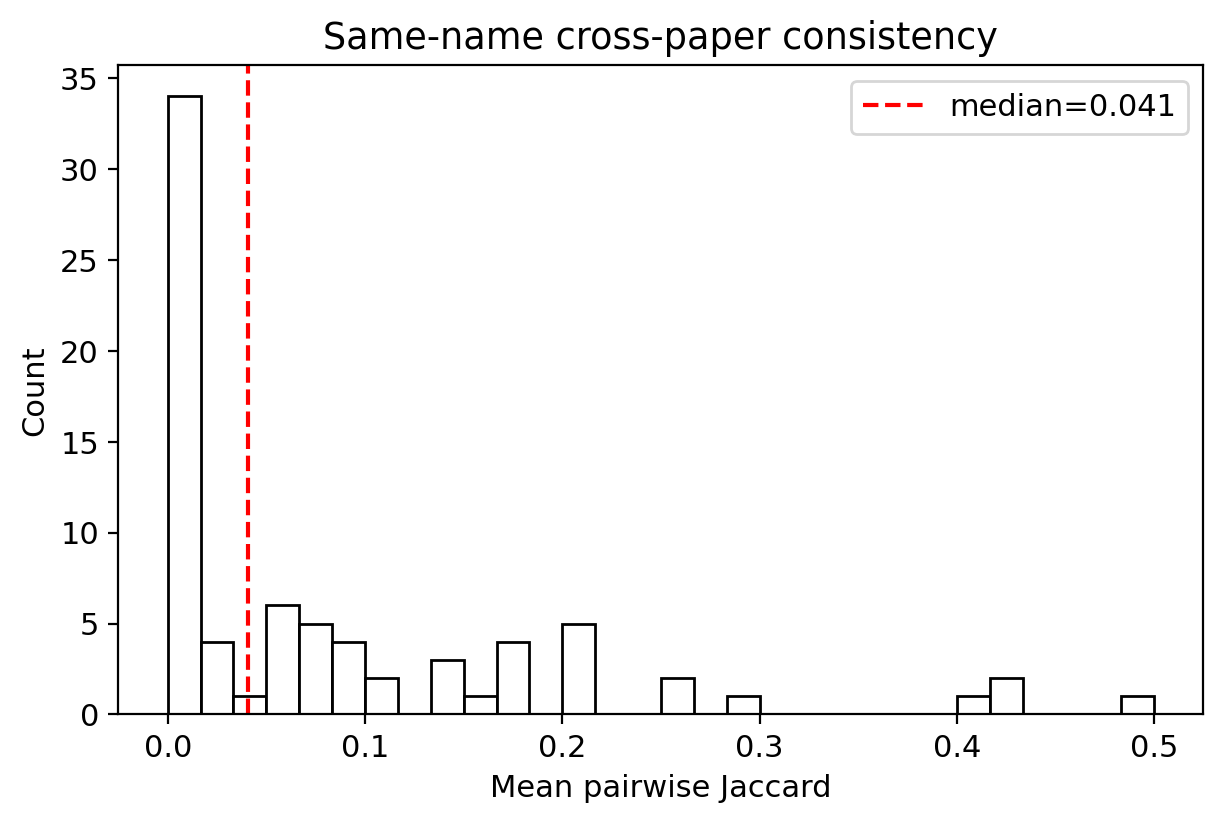

In [25]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(consistency_df["mean_jaccard"], bins=30, edgecolor="k", facecolor="white")
ax.axvline(consistency_df["mean_jaccard"].median(), color="red", ls="--",
           label=f"median={consistency_df['mean_jaccard'].median():.3f}")
ax.set(xlabel="Mean pairwise Jaccard", ylabel="Count",
       title="Same-name cross-paper consistency")
ax.legend()
plt.show()

## Summary

In [26]:
print("Cross-paper cell type matching summary")
print("=" * 50)
print(f"Total (paper, cell_type) profiles:    {len(filtered):,}")
print(f"Profiles after filtering (>= {MIN_MARKERS} markers): {len(filtered):,}")
print()
print("Nearest neighbor analysis (top-1 match per profile):")
print(f"  Best match is cross-paper:          {len(cross)} ({len(cross)/len(top1)*100:.1f}%)")
print(f"  Best match is within-paper:          {len(within)} ({len(within)/len(top1)*100:.1f}%)")
print()
print(f"Cross-paper different-name pairs (Jaccard >= 0.3): {(cross_diff_dedup['jaccard'] >= 0.3).sum()}")
print(f"Cross-paper different-name pairs (Jaccard >= 0.5): {(cross_diff_dedup['jaccard'] >= 0.5).sum()}")
print(f"Alias groups (Jaccard >= {JACC_THRESHOLD}):                    {len(components)}")
print(f"  with 2+ names:                       {sum(1 for c in components if len(c) >= 2)}")
print(f"  with 3+ names:                       {sum(1 for c in components if len(c) >= 3)}")
print()
print(f"Same-name cross-paper consistency:")
print(f"  Cell types in 2+ papers:             {len(consistency_df)}")
print(f"  Mean Jaccard:                        {consistency_df['mean_jaccard'].mean():.3f}")

Cross-paper cell type matching summary
Total (paper, cell_type) profiles:    1,039
Profiles after filtering (>= 3 markers): 1,039

Nearest neighbor analysis (top-1 match per profile):
  Best match is cross-paper:          724 (70.7%)
  Best match is within-paper:          300 (29.3%)

Cross-paper different-name pairs (Jaccard >= 0.3): 651
Cross-paper different-name pairs (Jaccard >= 0.5): 182
Alias groups (Jaccard >= 0.4):                    43
  with 2+ names:                       43
  with 3+ names:                       22

Same-name cross-paper consistency:
  Cell types in 2+ papers:             76
  Mean Jaccard:                        0.083
